# Reproducible HTZ forecast-to-construction illustration

This notebook is self-contained and requires no local CSV or other input file.
It requests the fixed post-relisting HTZ price window from the Yahoo Finance
chart endpoint and verifies the response against a SHA-256 digest. If the
request is unavailable or the returned data differ from the pinned snapshot,
the exact compressed history used in the paper is loaded from the notebook.

The frozen 11 May 2026 option menu is embedded as a literal table because the
expired 12 June 2026 chain is no longer available from a live historical-chain
endpoint.

The statistical evaluation uses chronological training, calibration, and test
blocks separated by two 23-trading-day embargoes. This ensures that every
response needed to fit or calibrate the procedure is observed before the next
block begins. After the model specification is evaluated, a separate
deployment fit uses the most recent eligible calibration block to produce the
8 May 2026 forecast.

The construction certifies nonnegative writer profit on an outward enlargement
of the raw predictive interval and imposes
\(\mathrm{Profit}(x)\geq-1\) for every \(x\geq0\).


In [1]:
from pathlib import Path
import base64
import hashlib
import io
import json
import math
import platform
import urllib.parse
import urllib.request
import zlib

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import Bounds, LinearConstraint, milp
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=10, suppress=True)
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.12.13
NumPy: 2.3.5
pandas: 2.2.3
scikit-learn: 1.8.0
SciPy: 1.17.0
Matplotlib: 3.10.8


In [2]:
TICKER = "HTZ"
HISTORY_START = "2021-11-09"
HISTORY_END_EXCLUSIVE = "2026-05-09"

def download_yahoo_history(ticker, start, end_exclusive, timeout=8):
    """Download a fixed daily-price window from Yahoo Finance."""
    period1 = int(pd.Timestamp(start, tz="UTC").timestamp())
    period2 = int(pd.Timestamp(end_exclusive, tz="UTC").timestamp())
    query = urllib.parse.urlencode({
        "period1": period1,
        "period2": period2,
        "interval": "1d",
        "events": "history",
        "includeAdjustedClose": "true",
    })
    url = (
        "https://query1.finance.yahoo.com/v8/finance/chart/"
        f"{ticker}?{query}"
    )
    request = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (HTZ research replication)"},
    )
    with urllib.request.urlopen(request, timeout=timeout) as response:
        payload = json.load(response)
    result = payload["chart"]["result"][0]
    quote = result["indicators"]["quote"][0]
    adjusted = result["indicators"]["adjclose"][0]["adjclose"]
    dates = (
        pd.to_datetime(result["timestamp"], unit="s", utc=True)
        .tz_convert(None)
        .normalize()
    )
    frame = pd.DataFrame({
        "Date": dates,
        "Open": quote["open"],
        "High": quote["high"],
        "Low": quote["low"],
        "Close": quote["close"],
        "AdjClose": adjusted,
        "Volume": quote["volume"],
    })
    frame = frame.dropna(subset=["AdjClose"]).reset_index(drop=True)
    float_columns = ["Open", "High", "Low", "Close", "AdjClose"]
    frame[float_columns] = frame[float_columns].round(10)
    return frame

FROZEN_HISTORY_B64 = """..."""

def embedded_frozen_history():
    raw = zlib.decompress(base64.b64decode(FROZEN_HISTORY_B64))
    return pd.read_csv(io.BytesIO(raw), parse_dates=["Date"])

try:
    prices = download_yahoo_history(
        TICKER, HISTORY_START, HISTORY_END_EXCLUSIVE
    )
    if (
        len(prices) != 1128
        or prices["Date"].min() != pd.Timestamp(HISTORY_START)
        or prices["Date"].max() != pd.Timestamp("2026-05-08")
    ):
        raise ValueError("Yahoo response does not match the pinned date window")
    canonical = prices.to_csv(
        index=False, float_format="%.10f", date_format="%Y-%m-%d"
    ).encode()
    downloaded_hash = hashlib.sha256(canonical).hexdigest()
    expected_hash = (
        "1381738c2df8614c38698e54b64eafc5216e8af88a6c1367f8e7201048308131"
    )
    if downloaded_hash != expected_hash:
        raise ValueError("Yahoo history differs from the pinned snapshot")
    price_source = "live Yahoo Finance chart download"
except Exception as download_error:
    prices = embedded_frozen_history()
    price_source = (
        "embedded frozen Yahoo snapshot "
        f"(live request unavailable: {type(download_error).__name__})"
    )

prices = prices.set_index("Date").sort_index()
print("Price source:", price_source)
canonical = prices.reset_index().to_csv(
    index=False, float_format="%.10f", date_format="%Y-%m-%d"
).encode()
print("Pinned history SHA-256:", hashlib.sha256(canonical).hexdigest())
print(
    f"HTZ observations: {len(prices)}; "
    f"{prices.index.min().date()} to {prices.index.max().date()}"
)
print("Latest adjusted close:", float(prices["AdjClose"].iloc[-1]))
assert len(prices) == 1128
assert prices.index.min() == pd.Timestamp("2021-11-09")
assert prices.index.max() == pd.Timestamp("2026-05-08")


Price source: live Yahoo Finance chart download
Pinned history SHA-256: 1381738c2df8614c38698e54b64eafc5216e8af88a6c1367f8e7201048308131
HTZ observations: 1128; 2021-11-09 to 2026-05-08
Latest adjusted close: 6.0500001907


## Statistical specification and leakage-free chronological split

- Response:
  \(Y_{t,h}=\log(S_{t+h}/S_t)\).
- Forecast horizon: \(h=23\) trading days.
- Nominal coverage: \(1-\alpha=0.90\).
- Sigmoidal family: one hidden layer with two logistic units.
- Score: absolute log-return residual.
- Radius: finite-sample corrected order statistic
  \(R_{(\lceil(n_{\rm cal}+1)(1-\alpha)\rceil)}\).
- Evaluation blocks: approximately 60% training, 20% calibration, and 20%
  untouched test after removing two embargoes of length \(h\).
- The redundant feature
  `rv63_ann = sqrt(252) * rv63` is deliberately omitted.


In [3]:
h = 23
alpha = 0.10
M = 2
train_fraction = 0.60
calibration_fraction = 0.20
random_state = 123
model_penalty = 1e-2
rounding_unit = 0.5

df = pd.DataFrame(index=prices.index)
df["Close"] = prices["AdjClose"].astype(float)
df["logS"] = np.log(df["Close"])
df["r1"] = df["logS"].diff()
df["r5"] = df["logS"].diff(5)
df["r21"] = df["logS"].diff(21)
df["r63"] = df["logS"].diff(63)
df["rv21"] = df["r1"].rolling(21).std()
df["rv63"] = df["r1"].rolling(63).std()
df["ma21_gap"] = df["Close"] / df["Close"].rolling(21).mean() - 1.0
df["ma63_gap"] = df["Close"] / df["Close"].rolling(63).mean() - 1.0
df["Y"] = df["logS"].shift(-h) - df["logS"]

feature_cols = [
    "r1", "r5", "r21", "r63", "rv21", "rv63",
    "ma21_gap", "ma63_gap",
]
labeled = df.dropna(subset=feature_cols + ["Y"]).copy()
latest = df.dropna(subset=feature_cols).iloc[-1:].copy()

X = labeled[feature_cols].to_numpy()
Y = labeled["Y"].to_numpy()
n = len(labeled)

usable_n = n - 2 * h
n_train = int(train_fraction * usable_n)
n_cal = int(calibration_fraction * usable_n)
n_test = usable_n - n_train - n_cal

train_slice = slice(0, n_train)
gap_1_slice = slice(n_train, n_train + h)
cal_start = n_train + h
cal_slice = slice(cal_start, cal_start + n_cal)
gap_2_start = cal_start + n_cal
gap_2_slice = slice(gap_2_start, gap_2_start + h)
test_start = gap_2_start + h
test_slice = slice(test_start, n)

origin_positions = df.index.get_indexer(labeled.index)
target_dates = df.index[origin_positions + h]

def print_block(name, sample_slice):
    block = labeled.iloc[sample_slice]
    positions = np.arange(n)[sample_slice]
    print(
        f"{name:12s}: {len(block):3d} origins; "
        f"{block.index.min().date()} to {block.index.max().date()}; "
        f"targets through {target_dates[positions[-1]].date()}"
    )

print("Labeled observations:", n)
print("Usable after two 23-day embargoes:", usable_n)
print_block("training", train_slice)
print_block("embargo 1", gap_1_slice)
print_block("calibration", cal_slice)
print_block("embargo 2", gap_2_slice)
print_block("test", test_slice)

assert target_dates[n_train - 1] < labeled.index[cal_start]
assert target_dates[cal_start + n_cal - 1] < labeled.index[test_start]
assert n_train + h + n_cal + h + n_test == n


Labeled observations: 1042
Usable after two 23-day embargoes: 996
training    : 597 origins; 2022-02-09 to 2024-06-26; targets through 2024-07-30
embargo 1   :  23 origins; 2024-06-27 to 2024-07-30; targets through 2024-08-30
calibration : 199 origins; 2024-07-31 to 2025-05-15; targets through 2025-06-18
embargo 2   :  23 origins; 2025-05-16 to 2025-06-18; targets through 2025-07-23
test        : 200 origins; 2025-06-20 to 2026-04-07; targets through 2026-05-08


In [4]:
def fit_sigmoidal_model(x, y):
    fitted = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(M,),
            activation="logistic",
            solver="lbfgs",
            alpha=model_penalty,
            max_iter=5000,
            random_state=random_state,
        )),
    ])
    fitted.fit(x, y)
    return fitted

def corrected_residual_quantile(scores, miscoverage):
    ordered = np.sort(np.asarray(scores, dtype=float))
    rank = min(
        math.ceil((len(ordered) + 1) * (1.0 - miscoverage)),
        len(ordered),
    )
    return float(ordered[rank - 1]), rank

evaluation_model = fit_sigmoidal_model(
    X[train_slice], Y[train_slice]
)
cal_prediction = evaluation_model.predict(X[cal_slice])
cal_scores = np.abs(Y[cal_slice] - cal_prediction)
q_evaluation, q_evaluation_rank = corrected_residual_quantile(
    cal_scores, alpha
)

print("Evaluation calibration size:", n_cal)
print("Corrected quantile rank:", q_evaluation_rank)
print(f"Evaluation calibration radius: {q_evaluation:.10f}")


Evaluation calibration size: 199
Corrected quantile rank: 180
Evaluation calibration radius: 0.6628188736


## Untouched test diagnostics and unconditional benchmark

The unconditional benchmark predicts a zero future log return and calibrates
its own corrected absolute-residual radius on exactly the same calibration
dates. The comparison is descriptive; it is not presented as evidence that the
sigmoidal forecast is superior.


In [5]:
test_prediction = evaluation_model.predict(X[test_slice])
test_truth = Y[test_slice]
test_close = labeled["Close"].to_numpy()[test_slice]

conditional_covered = (
    np.abs(test_truth - test_prediction) <= q_evaluation
)
conditional_width = test_close * (
    np.exp(test_prediction + q_evaluation)
    - np.exp(test_prediction - q_evaluation)
)

q_unconditional, q_unconditional_rank = corrected_residual_quantile(
    np.abs(Y[cal_slice]), alpha
)
unconditional_covered = np.abs(test_truth) <= q_unconditional
unconditional_width = test_close * (
    np.exp(q_unconditional) - np.exp(-q_unconditional)
)

diagnostics = pd.DataFrame([
    {
        "region": "sigmoidal conditional",
        "calibration_radius": q_evaluation,
        "test_covered": int(conditional_covered.sum()),
        "test_total": n_test,
        "test_coverage": float(conditional_covered.mean()),
        "mean_test_width": float(conditional_width.mean()),
    },
    {
        "region": "unconditional zero-return",
        "calibration_radius": q_unconditional,
        "test_covered": int(unconditional_covered.sum()),
        "test_total": n_test,
        "test_coverage": float(unconditional_covered.mean()),
        "mean_test_width": float(unconditional_width.mean()),
    },
])
print(diagnostics.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))


                   region  calibration_radius  test_covered  test_total  test_coverage  mean_test_width
    sigmoidal conditional            0.662819           200         200       1.000000         7.129464
unconditional zero-return            0.483726           192         200       0.960000         5.660217


## Final deployment fit and predictive interval

After the model specification has been evaluated on the untouched test block,
the deployment model is refitted using all eligible early observations. A
23-day embargo separates that fit from the most recent 208 labelled
observations, which calibrate the final radius. All targets in this recent
calibration block are observed by the 8 May 2026 forecast origin.


In [6]:
final_n_cal = int(0.20 * n)
final_cal_start = n - final_n_cal
final_train_end = final_cal_start - h

final_train_slice = slice(0, final_train_end)
final_gap_slice = slice(final_train_end, final_cal_start)
final_cal_slice = slice(final_cal_start, n)

deployment_model = fit_sigmoidal_model(
    X[final_train_slice], Y[final_train_slice]
)
deployment_cal_prediction = deployment_model.predict(
    X[final_cal_slice]
)
deployment_scores = np.abs(
    Y[final_cal_slice] - deployment_cal_prediction
)
q, q_rank = corrected_residual_quantile(deployment_scores, alpha)

S_latest = float(latest["Close"].iloc[0])
F_hat_latest = float(
    deployment_model.predict(
        latest[feature_cols].to_numpy()
    )[0]
)
G_lower = float(S_latest * np.exp(F_hat_latest - q))
G_upper = float(S_latest * np.exp(F_hat_latest + q))
G_conservative_lower = float(
    np.floor(G_lower / rounding_unit) * rounding_unit
)
G_conservative_upper = float(
    np.ceil(G_upper / rounding_unit) * rounding_unit
)

print_block("final train", final_train_slice)
print_block("final gap", final_gap_slice)
print_block("final calib.", final_cal_slice)
print("Final corrected quantile rank:", q_rank)
print(f"S_latest       = {S_latest:.10f}")
print(f"F_hat(z_t)     = {F_hat_latest:.10f}")
print(f"q              = {q:.10f}")
print(f"Raw G_alpha    = [{G_lower:.10f}, {G_upper:.10f}]")
print(
    "Outward-rounded construction region "
    f"= [{G_conservative_lower:.1f}, "
    f"{G_conservative_upper:.1f}]"
)

assert target_dates[final_train_end - 1] < labeled.index[final_cal_start]
assert target_dates[-1] == latest.index[-1]
assert G_conservative_lower <= G_lower
assert G_conservative_upper >= G_upper


final train : 811 origins; 2022-02-09 to 2025-05-05; targets through 2025-06-06
final gap   :  23 origins; 2025-05-06 to 2025-06-06; targets through 2025-07-11
final calib.: 208 origins; 2025-06-09 to 2026-04-07; targets through 2026-05-08
Final corrected quantile rank: 189
S_latest       = 6.0500001907
F_hat(z_t)     = -0.0432602973
q              = 0.3640831743
Raw G_alpha    = [4.0257645052, 8.3384819593]
Outward-rounded construction region = [4.0, 8.5]


## Embedded frozen Yahoo option menu

The target writer liability is \(f(x)=(x-5.3)^+\). Long positions execute at
the ask and short positions at the bid. The code selects the first listed call
strike at the outward-rounded upper boundary and the next listed call as the
protective cap. Thus the construction is linked programmatically, rather than
only verbally, to the computed predictive region.


In [7]:
OPTION_ROWS = [{'ticker': 'HTZ', 'option_type': 'call', 'strike': 5.5, 'bid': 0.85, 'ask': 1.03, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 6.0, 'bid': 0.62, 'ask': 0.76, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 6.5, 'bid': 0.42, 'ask': 0.57, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 7.0, 'bid': 0.29, 'ask': 0.43, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 7.5, 'bid': 0.18, 'ask': 0.33, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 8.0, 'bid': 0.14, 'ask': 0.25, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 8.5, 'bid': 0.1, 'ask': 0.2, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 9.0, 'bid': 0.04, 'ask': 0.23, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 9.5, 'bid': 0.02, 'ask': 0.26, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 10.0, 'bid': 0.05, 'ask': 0.24, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 10.5, 'bid': 0.0, 'ask': 0.24, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'call', 'strike': 13.0, 'bid': 0.0, 'ask': 0.29, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 3.0, 'bid': 0.0, 'ask': 0.31, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 3.5, 'bid': 0.0, 'ask': 0.2, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 4.0, 'bid': 0.06, 'ask': 0.2, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 4.5, 'bid': 0.11, 'ask': 0.2, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 5.0, 'bid': 0.2, 'ask': 0.33, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 5.5, 'bid': 0.35, 'ask': 0.5, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 6.0, 'bid': 0.6, 'ask': 0.72, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 6.5, 'bid': 0.9, 'ask': 1.0, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 7.0, 'bid': 1.26, 'ask': 1.4, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 7.5, 'bid': 1.66, 'ask': 1.8, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}, {'ticker': 'HTZ', 'option_type': 'put', 'strike': 8.0, 'bid': 1.88, 'ask': 2.25, 'snapshot_date': '2026-05-11', 'last_underlying_close_date': '2026-05-08', 'underlying_last': 6.0500001907, 'expiration': '2026-06-12', 'source': 'Frozen Yahoo Finance output from the archived construction run'}]
options = pd.DataFrame(OPTION_ROWS)
print(
    options[
        ["option_type", "strike", "bid", "ask", "snapshot_date", "expiration"]
    ].to_string(index=False)
)


option_type  strike  bid  ask snapshot_date expiration
       call     5.5 0.85 1.03    2026-05-11 2026-06-12
       call     6.0 0.62 0.76    2026-05-11 2026-06-12
       call     6.5 0.42 0.57    2026-05-11 2026-06-12
       call     7.0 0.29 0.43    2026-05-11 2026-06-12
       call     7.5 0.18 0.33    2026-05-11 2026-06-12
       call     8.0 0.14 0.25    2026-05-11 2026-06-12
       call     8.5 0.10 0.20    2026-05-11 2026-06-12
       call     9.0 0.04 0.23    2026-05-11 2026-06-12
       call     9.5 0.02 0.26    2026-05-11 2026-06-12
       call    10.0 0.05 0.24    2026-05-11 2026-06-12
       call    10.5 0.00 0.24    2026-05-11 2026-06-12
       call    13.0 0.00 0.29    2026-05-11 2026-06-12
        put     3.0 0.00 0.31    2026-05-11 2026-06-12
        put     3.5 0.00 0.20    2026-05-11 2026-06-12
        put     4.0 0.06 0.20    2026-05-11 2026-06-12
        put     4.5 0.11 0.20    2026-05-11 2026-06-12
        put     5.0 0.20 0.33    2026-05-11 2026-06-12
        pu

In [8]:
target_strike = 5.3
D = 1.0
tolerance = 1e-10

call_menu = options.loc[
    options["option_type"] == "call"
].sort_values("strike").reset_index(drop=True)
call_strikes = call_menu["strike"].to_numpy(float)
put_strikes = options.loc[
    options["option_type"] == "put", "strike"
].to_numpy(float)

target_hedge_strike = float(
    call_strikes[call_strikes >= target_strike].min()
)
boundary_candidates = call_strikes[
    call_strikes >= G_conservative_upper - tolerance
]
assert boundary_candidates.size > 0
boundary_strike = float(boundary_candidates.min())
cap_candidates = call_strikes[
    call_strikes > boundary_strike + tolerance
]
assert cap_candidates.size > 0
cap_strike = float(cap_candidates.min())

# If the option grid requires an additional outward enlargement, use it.
G_certified_lower = G_conservative_lower
G_certified_upper = boundary_strike
cap_width = cap_strike - boundary_strike
max_overlay = int(np.floor(D / cap_width + tolerance))
assert max_overlay >= 1

def option_quote(strike, side):
    row = call_menu.loc[
        np.isclose(call_menu["strike"], strike)
    ].iloc[0]
    return float(row[side])

target_ask = option_quote(target_hedge_strike, "ask")
boundary_bid = option_quote(boundary_strike, "bid")
cap_ask = option_quote(cap_strike, "ask")

# Variables: [cash, long target-hedging call,
#             short boundary call, long protective call].
cost = np.array([
    1.0, target_ask, -boundary_bid, cap_ask
])
integrality = np.array([0, 1, 1, 1])
variable_bounds = Bounds(
    np.array([-100.0, 0.0, 0.0, 0.0]),
    np.array([100.0, 2.0, max_overlay, max_overlay]),
)

def target_payoff(state):
    state = np.asarray(state, dtype=float)
    return np.maximum(state - target_strike, 0.0)

def payoff_row(state):
    return np.array([
        1.0,
        max(state - target_hedge_strike, 0.0),
        -max(state - boundary_strike, 0.0),
        max(state - cap_strike, 0.0),
    ])

regional_nodes = np.unique(np.r_[
    G_certified_lower,
    G_certified_upper,
    target_strike,
    call_strikes[
        (call_strikes >= G_certified_lower)
        & (call_strikes <= G_certified_upper)
    ],
    put_strikes[
        (put_strikes >= G_certified_lower)
        & (put_strikes <= G_certified_upper)
    ],
])
global_nodes = np.unique(np.r_[
    0.0, target_strike, call_strikes, put_strikes
])

rows, lower, upper = [], [], []
for state in regional_nodes:
    rows.append(payoff_row(state))
    lower.append(float(target_payoff(state)))
    upper.append(np.inf)
for state in global_nodes:
    rows.append(payoff_row(state))
    lower.append(float(target_payoff(state) - D))
    upper.append(np.inf)

# Every short boundary call is capped by one long call.
rows.append(np.array([0.0, 0.0, 1.0, -1.0]))
lower.append(0.0)
upper.append(0.0)

# Nonnegative asymptotic slope of portfolio payoff minus liability.
rows.append(np.array([0.0, 1.0, -1.0, 1.0]))
lower.append(1.0)
upper.append(np.inf)

base_constraint = LinearConstraint(
    np.asarray(rows), np.asarray(lower), np.asarray(upper)
)

# Stage 1: maximize capped exposure at the forecast boundary.
stage1 = milp(
    c=np.array([0.0, 0.0, -1.0, 0.0]),
    integrality=integrality,
    bounds=variable_bounds,
    constraints=base_constraint,
)
assert stage1.success, stage1.message
selected_overlay = int(round(stage1.x[2]))

# Stage 2: minimize setup cost at the selected exposure.
stage2_rows = np.vstack([
    np.asarray(rows), [0.0, 0.0, 1.0, 0.0]
])
stage2_lower = np.r_[lower, selected_overlay]
stage2_upper = np.r_[upper, selected_overlay]
result = milp(
    c=cost,
    integrality=integrality,
    bounds=variable_bounds,
    constraints=LinearConstraint(
        stage2_rows, stage2_lower, stage2_upper
    ),
)
assert result.success, result.message

solution = result.x
cash, long_target, short_boundary, long_cap = solution
J_cost = float(cost @ solution)
writer_premium = J_cost

print(
    f"Certified region: [{G_certified_lower:.1f}, "
    f"{G_certified_upper:.1f}]"
)
print(f"Target hedge strike: {target_hedge_strike:.1f}")
print(f"Boundary short strike: {boundary_strike:.1f}")
print(f"Protective cap strike: {cap_strike:.1f}")
print("Stage-1 maximum capped boundary spreads:", selected_overlay)
print("Stage-2 status:", result.message)
print(f"cash                         {cash:.6f}")
print(f"long call K={target_hedge_strike:.1f}             {long_target:.6f}")
print(f"short call K={boundary_strike:.1f}            {short_boundary:.6f}")
print(f"long call K={cap_strike:.1f}              {long_cap:.6f}")
print(f"Setup cost J_cost = {J_cost:.10f}")
print(f"Writer premium p_f = {writer_premium:.10f}")


Certified region: [4.0, 8.5]
Target hedge strike: 5.5
Boundary short strike: 8.5
Protective cap strike: 9.0
Stage-1 maximum capped boundary spreads: 2
Stage-2 status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
cash                         0.200000
long call K=5.5             1.000000
short call K=8.5            2.000000
long call K=9.0              2.000000
Setup cost J_cost = 1.4900000000
Writer premium p_f = 1.4900000000


In [9]:
def portfolio_payoff(state):
    state = np.asarray(state, dtype=float)
    return (
        cash
        + long_target * np.maximum(
            state - target_hedge_strike, 0.0
        )
        - short_boundary * np.maximum(
            state - boundary_strike, 0.0
        )
        + long_cap * np.maximum(state - cap_strike, 0.0)
    )

def writer_profit(state):
    return (
        writer_premium
        - J_cost
        + portfolio_payoff(state)
        - target_payoff(state)
    )

regional_certificate = pd.DataFrame({"x": regional_nodes})
regional_certificate["P(x)"] = portfolio_payoff(regional_nodes)
regional_certificate["f(x)"] = target_payoff(regional_nodes)
regional_certificate["Profit(x)"] = writer_profit(regional_nodes)
regional_certificate.loc[
    regional_certificate["Profit(x)"].abs() < 1e-10,
    "Profit(x)",
] = 0.0

print(regional_certificate.to_string(
    index=False, float_format=lambda value: f"{value:.10f}"
))
print(
    "Worst profit on the certified region:",
    float(regional_certificate["Profit(x)"].min()),
)
outside_check = boundary_strike + 0.1
print(
    f"Binding check Profit({outside_check:.1f}):",
    float(writer_profit(outside_check)),
)

assert regional_certificate["Profit(x)"].min() >= -1e-9
assert writer_profit(outside_check) < 0.0


           x         P(x)         f(x)    Profit(x)
4.0000000000 0.2000000000 0.0000000000 0.2000000000
4.5000000000 0.2000000000 0.0000000000 0.2000000000
5.0000000000 0.2000000000 0.0000000000 0.2000000000
5.3000000000 0.2000000000 0.0000000000 0.2000000000
5.5000000000 0.2000000000 0.2000000000 0.0000000000
6.0000000000 0.7000000000 0.7000000000 0.0000000000
6.5000000000 1.2000000000 1.2000000000 0.0000000000
7.0000000000 1.7000000000 1.7000000000 0.0000000000
7.5000000000 2.2000000000 2.2000000000 0.0000000000
8.0000000000 2.7000000000 2.7000000000 0.0000000000
8.5000000000 3.2000000000 3.2000000000 0.0000000000
Worst profit on the certified region: 0.0
Binding check Profit(8.6): -0.1999999999999993


In [10]:
global_certificate = pd.DataFrame({"x": global_nodes})
global_certificate["Profit(x)"] = writer_profit(global_nodes)
global_certificate.loc[
    global_certificate["Profit(x)"].abs() < 1e-10,
    "Profit(x)",
] = 0.0
tail_slope = (
    long_target - short_boundary + long_cap - 1.0
)

print(global_certificate.to_string(
    index=False, float_format=lambda value: f"{value:.10f}"
))
print(
    "Worst global-node profit:",
    float(global_certificate["Profit(x)"].min()),
)
print("Asymptotic net-profit slope:", tail_slope)
print("Accepted loss bound D:", D)

assert global_certificate["Profit(x)"].min() >= -D - 1e-9
assert tail_slope >= -1e-9
assert abs(float(writer_profit(cap_strike)) + D) < 1e-9
assert abs(float(writer_profit(10000.0)) + D) < 1e-9


            x     Profit(x)
 0.0000000000  0.2000000000
 3.0000000000  0.2000000000
 3.5000000000  0.2000000000
 4.0000000000  0.2000000000
 4.5000000000  0.2000000000
 5.0000000000  0.2000000000
 5.3000000000  0.2000000000
 5.5000000000  0.0000000000
 6.0000000000  0.0000000000
 6.5000000000  0.0000000000
 7.0000000000  0.0000000000
 7.5000000000  0.0000000000
 8.0000000000  0.0000000000
 8.5000000000  0.0000000000
 9.0000000000 -1.0000000000
 9.5000000000 -1.0000000000
10.0000000000 -1.0000000000
10.5000000000 -1.0000000000
13.0000000000 -1.0000000000
Worst global-node profit: -1.0
Asymptotic net-profit slope: 0.0
Accepted loss bound D: 1.0


## Profit graph on \(x\in[0,20]\)

The vertical green band is the certified predictive region. Green and red
payoff fills distinguish gains from losses. The profit decreases only between
the boundary strike and its protective cap and then remains at \(-D=-1\).


figures/htz_profit_bounded_loss.png
figures/htz_profit_bounded_loss.pdf
Minimum plotted profit: -1.0


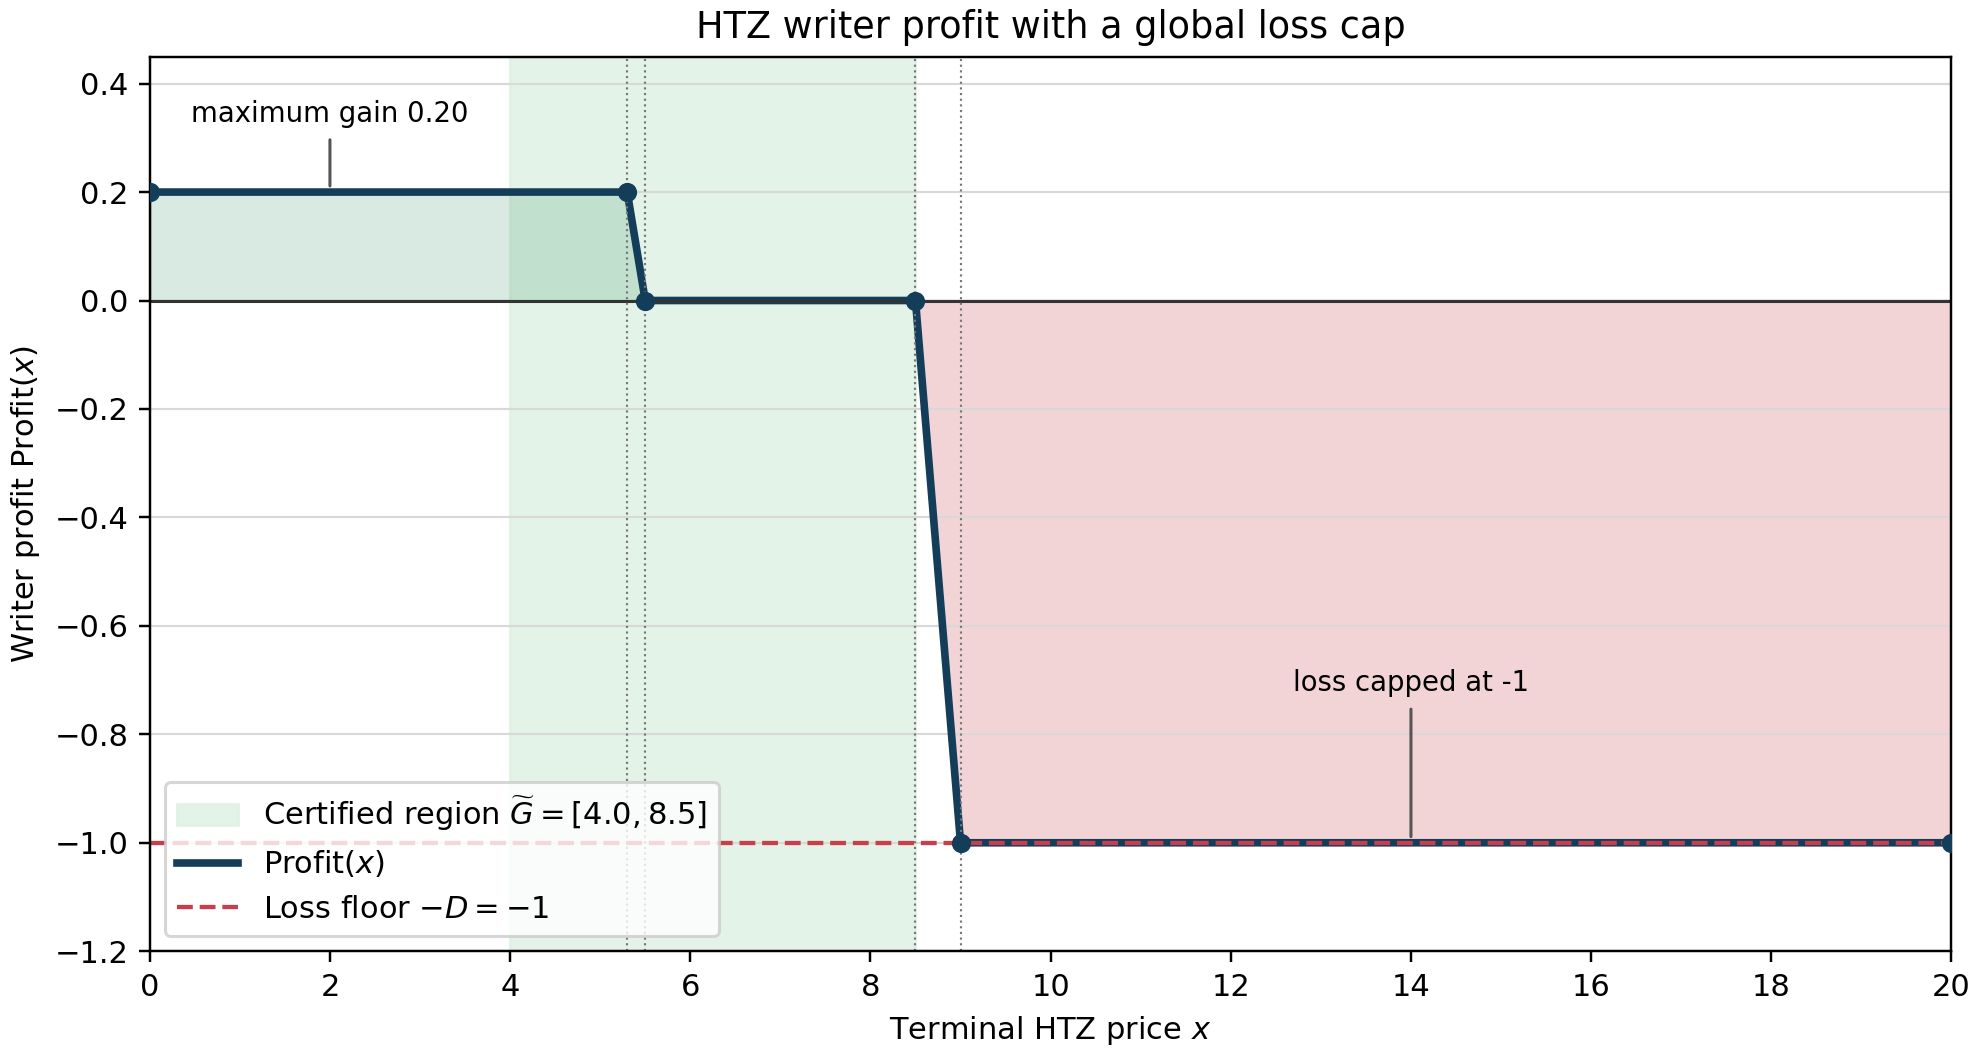

In [11]:
x_plot = np.linspace(0.0, 20.0, 2001)
y_plot = writer_profit(x_plot)

fig, ax = plt.subplots(
    figsize=(9.0, 4.8), constrained_layout=True
)
ax.axvspan(
    G_certified_lower,
    G_certified_upper,
    color="#dff1e3",
    alpha=0.85,
    label=(
        r"Certified region $\widetilde G="
        f"[{G_certified_lower:.1f},{G_certified_upper:.1f}]$"
    ),
)
ax.fill_between(
    x_plot, y_plot, 0.0, where=y_plot >= 0.0,
    color="#2b8c5a", alpha=0.18,
)
ax.fill_between(
    x_plot, y_plot, 0.0, where=y_plot < 0.0,
    color="#c83e4d", alpha=0.22,
)
ax.plot(
    x_plot, y_plot, color="#143d59", linewidth=2.5,
    label=r"$\mathrm{Profit}(x)$",
)
ax.axhline(0.0, color="#333333", linewidth=1.0)
ax.axhline(
    -D, color="#c83e4d", linewidth=1.4, linestyle="--",
    label=r"Loss floor $-D=-1$",
)
for breakpoint in (
    target_strike,
    target_hedge_strike,
    boundary_strike,
    cap_strike,
):
    ax.axvline(
        breakpoint, color="#777777", linewidth=0.7,
        linestyle=":",
    )
ax.scatter(
    [
        0.0,
        target_strike,
        target_hedge_strike,
        boundary_strike,
        cap_strike,
        20.0,
    ],
    writer_profit([
        0.0,
        target_strike,
        target_hedge_strike,
        boundary_strike,
        cap_strike,
        20.0,
    ]),
    color="#143d59", s=28, zorder=4,
)
ax.annotate(
    f"maximum gain {cash:.2f}",
    xy=(2.0, cash),
    xytext=(2.0, cash + 0.13),
    ha="center",
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": "#555555"},
)
ax.annotate(
    "loss capped at -1",
    xy=(14.0, -1.0),
    xytext=(14.0, -0.72),
    ha="center",
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": "#555555"},
)
ax.set_xlim(0.0, 20.0)
ax.set_ylim(-1.20, 0.45)
ax.set_xticks(np.arange(0.0, 20.1, 2.0))
ax.set_xlabel(r"Terminal HTZ price $x$")
ax.set_ylabel(r"Writer profit $\mathrm{Profit}(x)$")
ax.set_title("HTZ writer profit with a global loss cap")
ax.grid(axis="y", color="#d8d8d8", linewidth=0.7)
ax.legend(loc="lower left", frameon=True)

png_path = FIGURES_DIR / "htz_profit_bounded_loss.png"
pdf_path = FIGURES_DIR / "htz_profit_bounded_loss.pdf"
fig.savefig(png_path, dpi=220)
fig.savefig(pdf_path)
print(png_path.relative_to(Path.cwd()))
print(pdf_path.relative_to(Path.cwd()))
print("Minimum plotted profit:", float(y_plot.min()))


## Historical-state payoff diagnostic

The following calculation applies the one final illustrative payoff to the
terminal prices in the purged test block. It is a historical-state stress
diagnostic only. It is not a rolling hedging backtest and is not used as a
coverage-to-profit theorem check, because no contemporaneous option menu is
available for each historical origin.


In [12]:
test_terminal_prices = (
    labeled["Close"].to_numpy()[test_slice]
    * np.exp(test_truth)
)
test_state_profit = writer_profit(test_terminal_prices)
state_nonnegative = test_state_profit >= -1e-10

print(
    "Historical test states with nonnegative final payoff:",
    f"{int(state_nonnegative.sum())}/{n_test}",
    f"= {state_nonnegative.mean():.6f}",
)
print(
    "Test terminal-price range:",
    f"[{test_terminal_prices.min():.10f}, "
    f"{test_terminal_prices.max():.10f}]",
)
print(
    "Minimum payoff across historical test states:",
    float(test_state_profit.min()),
)


Historical test states with nonnegative final payoff: 200/200 = 1.000000
Test terminal-price range: [3.8900001049, 7.8099999428]
Minimum payoff across historical test states: 0.0


## Reproduced objects

- Leakage-free evaluation: 597 training, 199 calibration, and 200 test
  observations, separated by two 23-day embargoes.
- Final raw predictive interval and every outward-enlargement step are printed.
- The option strikes are selected from the computed upper boundary.
- Long positions use ask quotes and short positions use bid quotes.
- The full regional and global certificates are printed.
- The resulting payoff is nonnegative on the certified region and bounded
  below by \(-1\) on the whole state space.
